<a href="https://colab.research.google.com/github/Anu-253/rep/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#loading dataset
dataset = pd.read_csv("diabetes.csv")
dataset


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Text(0.5, 1.0, 'Correlation heatmap')

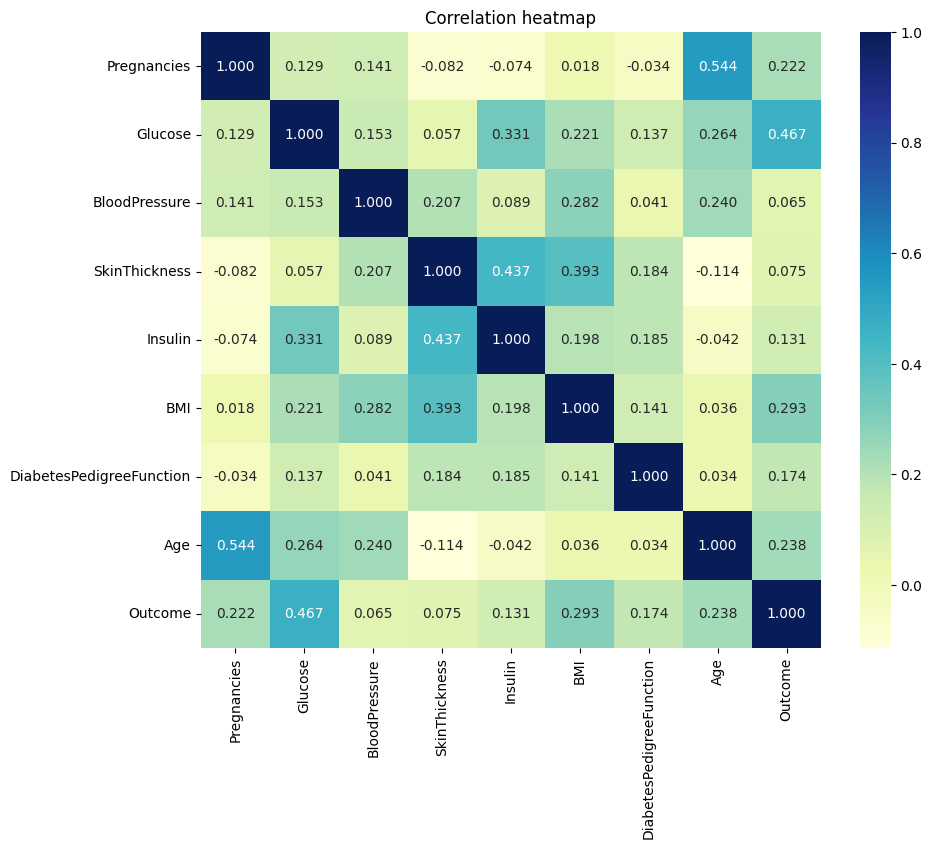

In [6]:
#correlation of plot independent variables
plt.figure(figsize = (10,8))
sns.heatmap(dataset.corr(), annot = True, fmt =".3f" , cmap = "YlGnBu")
plt.title("Correlation heatmap")

/tmp/ipython-input-4198731077.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==1], color="Red", shade=True, label="Positive")
/tmp/ipython-input-4198731077.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==0], color="Blue", shade=True, label="Negative")


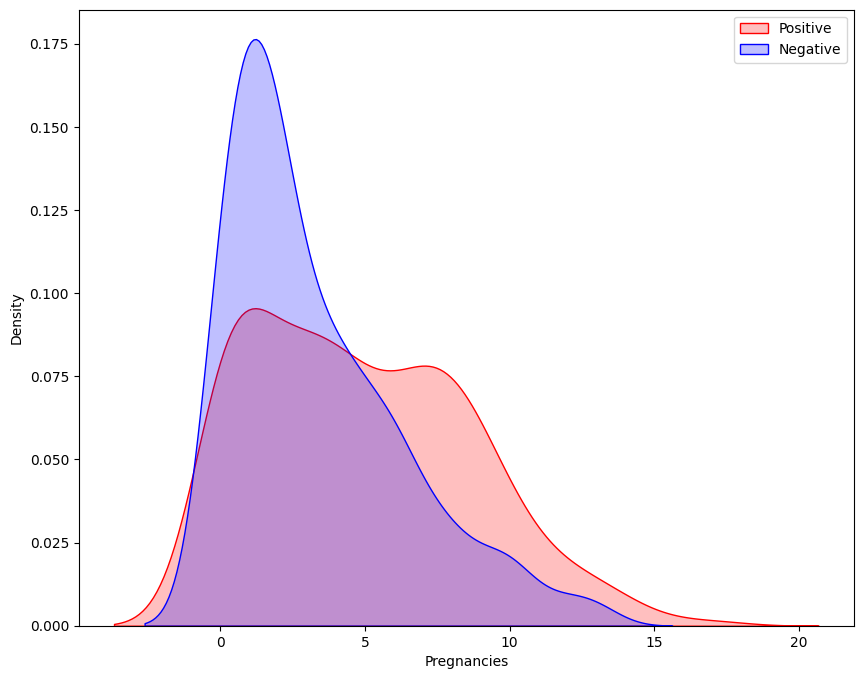

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==1], color="Red", shade=True, label="Positive")
sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==0], color="Blue", shade=True, label="Negative")

plt.xlabel("Pregnancies")
plt.ylabel("Density")
plt.legend()
plt.show()


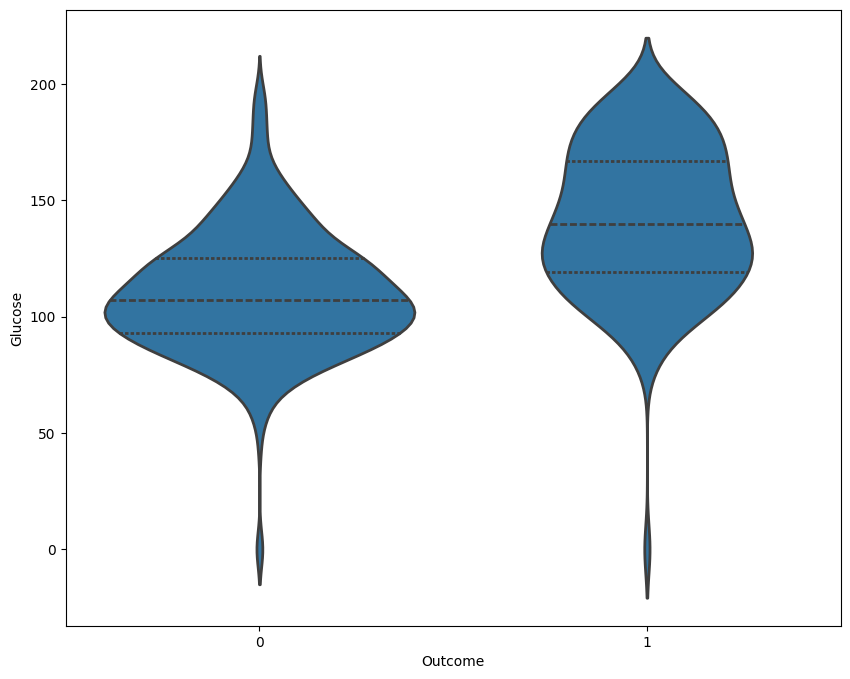

In [8]:
plt.figure(figsize=(10,8))
sns.violinplot(data=dataset, x="Outcome", y="Glucose", linewidth=2, inner="quart")
plt.show()

In [9]:
#Splitting the dependent and independent variable
X = dataset.drop(["Outcome"],axis = 1)
y = dataset["Outcome"]

In [10]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [11]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [12]:
# Splitting the dataset into training and testing dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
464,10,115,98,0,0,24.0,1.022,34
223,7,142,60,33,190,28.8,0.687,61
393,4,116,72,12,87,22.1,0.463,37
766,1,126,60,0,0,30.1,0.349,47
570,3,78,70,0,0,32.5,0.270,39
...,...,...,...,...,...,...,...,...
71,5,139,64,35,140,28.6,0.411,26
106,1,96,122,0,0,22.4,0.207,27
270,10,101,86,37,0,45.6,1.136,38
435,0,141,0,0,0,42.4,0.205,29


In [13]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

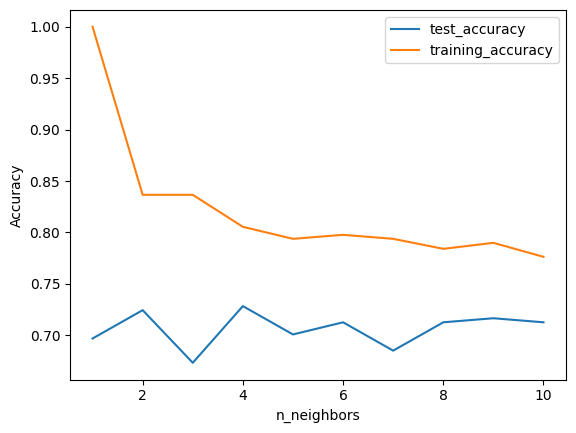

In [14]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

training_accuracy = []
test_accuracy = []

for n_neighbors in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # check accuracy score
    training_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

import matplotlib.pyplot as plt

plt.plot(range(1, 11), test_accuracy, label = "test_accuracy")
plt.plot(range(1, 11), training_accuracy, label = "training_accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [15]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
print(knn.score(X_train, y_train), ":Training accuracy")
print(knn.score(X_test, y_test), ":Test accuracy")

0.7898832684824902 :Training accuracy
0.7165354330708661 :Test accuracy


In [18]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(random_state = 0)
dt1.fit(X_train, y_train)
print(dt1.score(X_train, y_train), ":Training accuracy")
print(dt1.score(X_test, y_test), ":Test accuracy")

1.0 :Training accuracy
0.7086614173228346 :Test accuracy


In [19]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(random_state=42, max_iter=300)
mlp.fit(X_train, y_train)
print(mlp.score(X_train, y_train), ":Training accuracy")
print(mlp.score(X_test, y_test), ":Test accuracy")

0.7704280155642024 :Training accuracy
0.7047244094488189 :Test accuracy


In [20]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_sc = sc.transform(X_train)
X_test_sc = sc.transform(X_test)

In [21]:
mlp1 = MLPClassifier(random_state=42, max_iter=300)
mlp1.fit(X_train_sc, y_train)
print(mlp1.score(X_train_sc, y_train), ":Training accuracy")
print(mlp1.score(X_test_sc, y_test), ":Test accuracy")

0.8482490272373541 :Training accuracy
0.7283464566929134 :Test accuracy


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
